# US16 — Comparação do Rendimento Total por Cargo (Role)

**Descrição:**  
Como membro do Comité de Ética, quero obter uma comparação do rendimento total (salário bruto + rendimentos laterais) entre os diferentes cargos. A análise deve usar boxplots para revelar diferenças na tendência central, variabilidade e presença de outliers. O objetivo é identificar qual(ais) cargo(s) apresenta(m) as medianas mais elevadas e qual(ais) exibe(m) maior dispersão, listando e interpretando os outliers detetados.

---

## Conceitos Teóricos Aplicados

### Rendimento Total
O rendimento total de cada agente político é calculado como:

$$\text{total\_income} = \text{gross\_salary} + \text{side\_income\_consulting} + \text{side\_income\_board\_memberships}$$

### Mediana (Medida de Localização Central)
Dado um conjunto de $n$ valores ordenados $x_{(1)} \leq x_{(2)} \leq \ldots \leq x_{(n)}$, a mediana é:

$$\tilde{x} = \begin{cases} \dfrac{x_{(n/2)} + x_{(n/2+1)}}{2}, & \text{se } n \text{ par} \\ x_{((n+1)/2)}, & \text{se } n \text{ ímpar} \end{cases}$$

### Amplitude Interquartil (Medida de Variabilidade)
$$r_q = q_3 - q_1$$
Representa como estão dispersos 50% das observações centrais.

### Outliers — Critério do Boxplot
Um valor é considerado outlier se estiver fora dos limites:
$$[q_1 - 1{,}5 \times r_q \;,\; q_3 + 1{,}5 \times r_q]$$

### Diagrama de Extremos e Quartis (Boxplot)
Representação gráfica dos valores: mínimo, $q_1$, mediana, $q_3$, máximo.
Os outliers são representados isoladamente como pontos fora dos "bigodes".

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/dataset1_declarations.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

# ── Cálculo do Rendimento Total ─────────────────────────────────────────────
# total_income = salário bruto + rendimentos de consultoria + rendimentos de memberships
df['total_income'] = (
    df['gross_salary'] +
    df['side_income_consulting'] +
    df['side_income_board_memberships']
)

print(f"Dataset carregado: {df.shape[0]} declarações, {df['agent_id'].nunique()} agentes únicos")
print(f"Cargos presentes: {sorted(df['role'].unique())}")

Dataset carregado: 13395 declarações, 2364 agentes únicos
Cargos presentes: ['Advisor', 'Judge', 'MP', 'Minister', 'State Secretary']


## 1. Medidas Descritivas do Rendimento Total por Cargo

Para cada cargo calculamos as principais medidas de localização e variabilidade do rendimento total.

In [7]:
# ── Medidas descritivas agrupadas por cargo ─────────────────────────────────
# Média, Mediana, Desvio Padrão, Variância, Q1, Q3, Amplitude Interquartil

def medidas_descritivas(grupo):
    q1 = grupo.quantile(0.25)
    q3 = grupo.quantile(0.75)
    return pd.Series({
        'Média':              grupo.mean(),
        'Mediana':            grupo.median(),
        'Desvio Padrão':      grupo.std(),
        'Variância':          grupo.var(),
        'Q1 (25%)':           q1,
        'Q3 (75%)':           q3,
        'Amplitude Interquartil (IQR)': q3 - q1,
        'Mínimo':             grupo.min(),
        'Máximo':             grupo.max(),
        'N (declarações)':    grupo.count()
    })

tabela = df.groupby('role')['total_income'].apply(medidas_descritivas)
# No pandas moderno o resultado pode ter MultiIndex — garantir estrutura correcta
if isinstance(tabela.index, pd.MultiIndex):
    tabela = tabela.unstack(level=0)
else:
    tabela = tabela.T

# Ordenar colunas pela mediana decrescente
ordem = tabela.loc['Mediana'].sort_values(ascending=False).index
tabela = tabela[ordem]

print("=" * 90)
print("MEDIDAS DESCRITIVAS DO RENDIMENTO TOTAL POR CARGO")
print("=" * 90)
print(tabela.map(lambda x: f"{x:,.2f}" if isinstance(x, float) else str(x)).to_string())
print()
print(f"→ Cargo com mediana mais elevada : {tabela.loc['Mediana'].idxmax()}")
print(f"→ Cargo com maior dispersão (IQR): {tabela.loc['Amplitude Interquartil (IQR)'].idxmax()}")
print(f"→ Cargo com maior desvio padrão  : {tabela.loc['Desvio Padrão'].idxmax()}")

MEDIDAS DESCRITIVAS DO RENDIMENTO TOTAL POR CARGO
role                                        MP           Advisor   State Secretary        Minister             Judge
Média                               101,061.63        101,270.07        100,297.60       96,156.69         99,711.46
Mediana                              96,782.07         96,513.30         95,452.29       95,311.96         94,857.93
Desvio Padrão                        32,878.24         32,854.22         33,447.63       31,015.85         32,127.13
Variância                     1,080,978,869.77  1,079,400,071.19  1,118,743,714.02  961,983,090.59  1,032,152,522.97
Q1 (25%)                             78,556.45         79,122.16         77,431.62       74,221.19         77,199.42
Q3 (75%)                            118,637.58        118,802.40        117,786.86      111,907.25        116,453.33
Amplitude Interquartil (IQR)         40,081.12         39,680.24         40,355.24       37,686.07         39,253.91
Mínimo        

## 2. Boxplot — Comparação do Rendimento Total por Cargo

O boxplot permite visualizar simultaneamente a mediana, a dispersão interquartil e a presença de outliers para cada cargo.

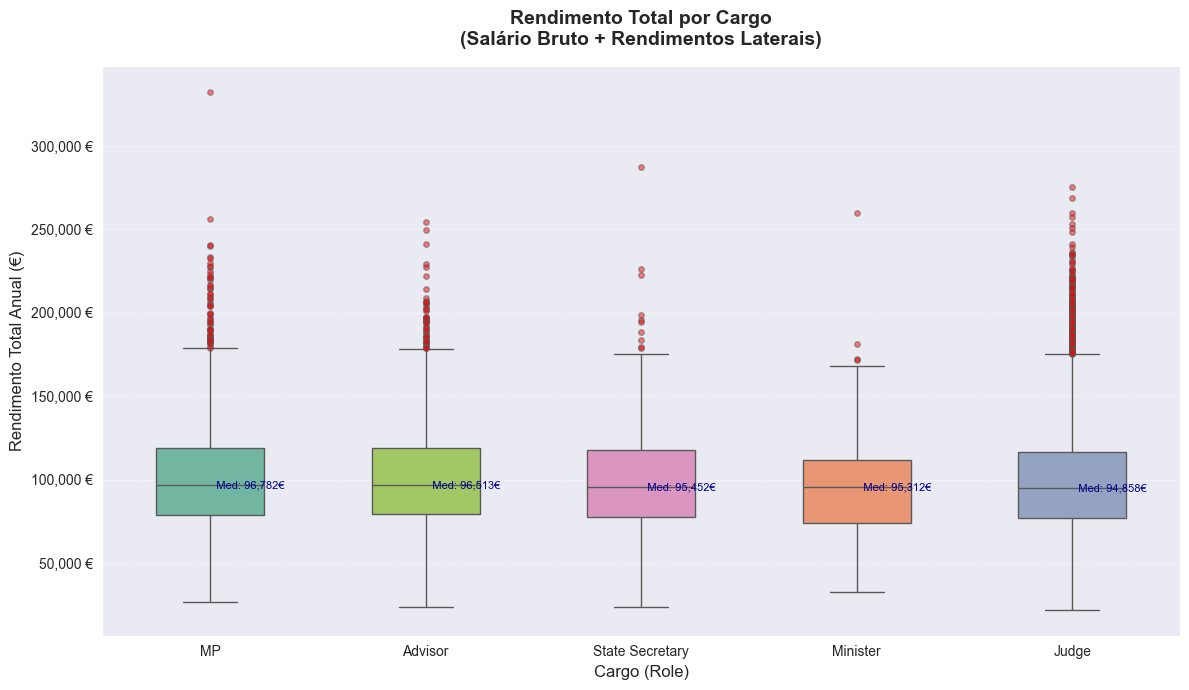

Gráfico guardado em: US16_boxplot_rendimento_por_cargo.svg


In [8]:
# ── Ordem dos cargos por mediana decrescente ────────────────────────────────
ordem_cargos = (
    df.groupby('role')['total_income']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='role', y='total_income',
    order=ordem_cargos,
    hue='role', palette='Set2', legend=False,
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5),
    ax=ax
)

ax.set_title(
    'Rendimento Total por Cargo\n'
    '(Salário Bruto + Rendimentos Laterais)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Cargo (Role)', fontsize=12)
ax.set_ylabel('Rendimento Total Anual (€)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Anotar a mediana em cada caixa
medianas = df.groupby('role')['total_income'].median()
for i, cargo in enumerate(ordem_cargos):
    ax.text(
        i, medianas[cargo],
        f'  Med: {medianas[cargo]:,.0f}€',
        va='center', fontsize=8, color='darkblue'
    )

plt.tight_layout()
plt.savefig('US16_boxplot_rendimento_por_cargo.svg', format='svg', bbox_inches='tight')
plt.show()
print("Gráfico guardado em: US16_boxplot_rendimento_por_cargo.svg")

## 3. Identificação e Interpretação de Outliers

Usando o critério standard do boxplot:  
$$\text{Outlier se } x < q_1 - 1{,}5 \times IQR \quad \text{ou} \quad x > q_3 + 1{,}5 \times IQR$$

In [9]:
# ── Deteção de Outliers por Cargo ───────────────────────────────────────────
resumo_outliers = []

print("=" * 90)
print("OUTLIERS DETETADOS — RENDIMENTO TOTAL POR CARGO")
print("=" * 90)

for cargo in ordem_cargos:
    sub = df[df['role'] == cargo]['total_income']
    q1  = sub.quantile(0.25)
    q3  = sub.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers_inf = sub[sub < lim_inf]
    outliers_sup = sub[sub > lim_sup]
    todos = pd.concat([outliers_inf, outliers_sup]).sort_values()

    print(f"\nCargo: {cargo}")
    print(f"  Q1={q1:,.0f}€ | Q3={q3:,.0f}€ | IQR={iqr:,.0f}€")
    print(f"  Limite inferior: {lim_inf:,.0f}€ | Limite superior: {lim_sup:,.0f}€")
    print(f"  Outliers inferiores: {len(outliers_inf)} | Outliers superiores: {len(outliers_sup)} | Total: {len(todos)}")

    if len(todos) > 0:
        print(f"  Min outlier: {todos.min():,.0f}€ | Max outlier: {todos.max():,.0f}€")

    resumo_outliers.append({
        'Cargo':              cargo,
        'N Outliers':         len(todos),
        'Outliers Inf.':      len(outliers_inf),
        'Outliers Sup.':      len(outliers_sup),
        'Limite Inferior (€)': round(lim_inf, 2),
        'Limite Superior (€)': round(lim_sup, 2)
    })

# Tabela resumo
print("\n" + "=" * 90)
print("RESUMO DE OUTLIERS")
print(pd.DataFrame(resumo_outliers).set_index('Cargo').to_string())

OUTLIERS DETETADOS — RENDIMENTO TOTAL POR CARGO

Cargo: MP
  Q1=78,556€ | Q3=118,638€ | IQR=40,081€
  Limite inferior: 18,435€ | Limite superior: 178,759€
  Outliers inferiores: 0 | Outliers superiores: 59 | Total: 59
  Min outlier: 178,789€ | Max outlier: 332,624€

Cargo: Advisor
  Q1=79,122€ | Q3=118,802€ | IQR=39,680€
  Limite inferior: 19,602€ | Limite superior: 178,323€
  Outliers inferiores: 0 | Outliers superiores: 47 | Total: 47
  Min outlier: 178,858€ | Max outlier: 254,288€

Cargo: State Secretary
  Q1=77,432€ | Q3=117,787€ | IQR=40,355€
  Limite inferior: 16,899€ | Limite superior: 178,320€
  Outliers inferiores: 0 | Outliers superiores: 10 | Total: 10
  Min outlier: 178,714€ | Max outlier: 287,333€

Cargo: Minister
  Q1=74,221€ | Q3=111,907€ | IQR=37,686€
  Limite inferior: 17,692€ | Limite superior: 168,436€
  Outliers inferiores: 0 | Outliers superiores: 4 | Total: 4
  Min outlier: 171,768€ | Max outlier: 259,849€

Cargo: Judge
  Q1=77,199€ | Q3=116,453€ | IQR=39,254€
  L

## 4. Interpretação dos Resultados

Com base na análise efectuada, é possível retirar as seguintes conclusões:

In [10]:
# ── Interpretação automática ────────────────────────────────────────────────
tab = pd.DataFrame(resumo_outliers).set_index('Cargo')
medianas_cargo = df.groupby('role')['total_income'].median()
iqr_cargo      = df.groupby('role')['total_income'].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))

cargo_maior_mediana  = medianas_cargo.idxmax()
cargo_maior_disp     = iqr_cargo.idxmax()
cargo_mais_outliers  = tab['N Outliers'].idxmax()

print("INTERPRETAÇÃO")
print("-" * 60)
print(f"• Cargo com mediana mais elevada  : {cargo_maior_mediana} ({medianas_cargo[cargo_maior_mediana]:,.0f} €)")
print(f"  → É o cargo com o rendimento típico mais alto.")
print()
print(f"• Cargo com maior dispersão (IQR) : {cargo_maior_disp} ({iqr_cargo[cargo_maior_disp]:,.0f} €)")
print(f"  → Os rendimentos neste cargo variam mais entre os agentes.")
print()
print(f"• Cargo com mais outliers         : {cargo_mais_outliers} ({tab.loc[cargo_mais_outliers, 'N Outliers']} outliers)")
print(f"  → Existem agentes com rendimentos atipicamente elevados ou baixos.")
print()
print("• Outliers superiores indicam possíveis rendimentos laterais muito")
print("  elevados (consulting ou board memberships) que merecem atenção")
print("  do Comité de Ética quanto a potenciais conflitos de interesse.")

INTERPRETAÇÃO
------------------------------------------------------------
• Cargo com mediana mais elevada  : MP (96,782 €)
  → É o cargo com o rendimento típico mais alto.

• Cargo com maior dispersão (IQR) : State Secretary (40,355 €)
  → Os rendimentos neste cargo variam mais entre os agentes.

• Cargo com mais outliers         : Judge (236 outliers)
  → Existem agentes com rendimentos atipicamente elevados ou baixos.

• Outliers superiores indicam possíveis rendimentos laterais muito
  elevados (consulting ou board memberships) que merecem atenção
  do Comité de Ética quanto a potenciais conflitos de interesse.
